In [11]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load dataframe
df = pd.read_csv('mod_features_df.csv')
df.head()

,query_id,query_contents,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,...,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,best_model,Best Alpha,MRR
0,1048585,what is paula deen's brother,6,2,4,0.333333,0.666667,1,0,0,...,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846,bm25,0.00,0.333333
1,2,Androgen receptor define,3,0,3,0.000000,1.000000,0,0,0,...,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653,splade,0.00,1.000000
2,524332,treating tension headaches without medication,5,0,5,0.000000,1.000000,0,0,0,...,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385,repllama,1.00,0.023810
3,1048642,what is paranoid sc,4,2,2,0.500000,0.500000,1,0,0,...,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258,splade,0.62,0.100000
4,524447,treatment of varicose veins in legs,6,2,4,0.333333,0.666667,0,0,0,...,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383,repllama,0.89,0.024390


In [13]:
# X and y dataframes
X = df.drop(columns=['Best Alpha', 'query_contents', 'best_model'], axis=1)
y = np.asarray(df['Best Alpha'], dtype="float64")

X.head()

,query_id,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,why,...,cls_759,cls_760,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,MRR
0,1048585,6,2,4,0.333333,0.666667,1,0,0,0,...,-0.371679,0.132870,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846,0.333333
1,2,3,0,3,0.000000,1.000000,0,0,0,0,...,-0.239406,-0.098719,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653,1.000000
2,524332,5,0,5,0.000000,1.000000,0,0,0,0,...,-0.523775,0.629171,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385,0.023810
3,1048642,4,2,2,0.500000,0.500000,1,0,0,0,...,-0.263777,0.258236,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258,0.100000
4,524447,6,2,4,0.333333,0.666667,0,0,0,0,...,-0.287455,0.245836,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383,0.024390


In [14]:
print(X.shape)

(6980, 781)


In [15]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# Training and testing sets (CHANGE TEST SIZE?)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [17]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    verbose=True
)

In [18]:
print(y_train)

[0.   0.   0.41 ... 0.   0.01 0.  ]


In [19]:
# Train/fit model
mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)

Iteration 1, loss = 0.29431595
Iteration 2, loss = 0.10290208
Iteration 3, loss = 0.06600933
Iteration 4, loss = 0.05027488
Iteration 5, loss = 0.03958434
Iteration 6, loss = 0.03257903
Iteration 7, loss = 0.02779955
Iteration 8, loss = 0.02311120
Iteration 9, loss = 0.01953936
Iteration 10, loss = 0.01665947
Iteration 11, loss = 0.01440865
Iteration 12, loss = 0.01285168
Iteration 13, loss = 0.01158130
Iteration 14, loss = 0.01002168
Iteration 15, loss = 0.00858792
Iteration 16, loss = 0.00749565
Iteration 17, loss = 0.00665653
Iteration 18, loss = 0.00576007
Iteration 19, loss = 0.00507628
Iteration 20, loss = 0.00461766
Iteration 21, loss = 0.00418073
Iteration 22, loss = 0.00365042
Iteration 23, loss = 0.00334048
Iteration 24, loss = 0.00297743
Iteration 25, loss = 0.00257911
Iteration 26, loss = 0.00228048
Iteration 27, loss = 0.00217039
Iteration 28, loss = 0.00195310
Iteration 29, loss = 0.00175595
Iteration 30, loss = 0.00158607
Iteration 31, loss = 0.00149179
Iteration 32, los

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Checking errors
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


MSE: 0.2390
RMSE: 0.4888
MAE: 0.3916
R²: -1.0682


In [21]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, validation_curve
import seaborn as sns

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}")

Train MSE: 0.0057, Test MSE: 0.2390
Train R2: 0.9533, Test R2: -1.0682


Min: -0.533004319110992 , Max: 1.6253170660172094


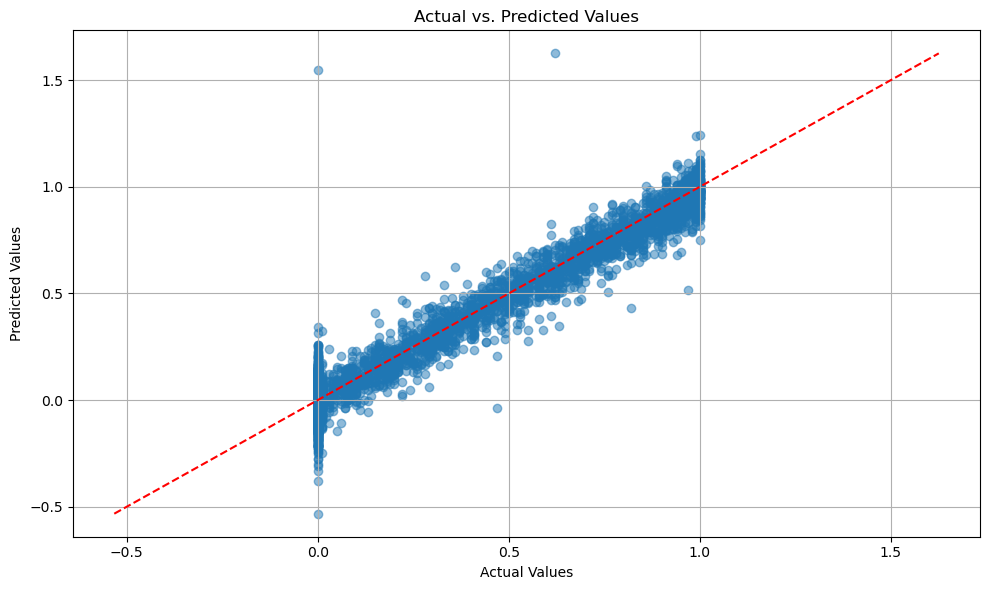

In [22]:
# Training data plot
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred_train, alpha=0.5)

min_val = min(min(y_train), min(y_pred_train))
max_val = max(max(y_train), max(y_pred_train))
print("Min:", min_val, ", Max:", max_val)
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.tight_layout()
plt.show()

Min: -1.3669619983305652 , Max: 1.4818632870143769


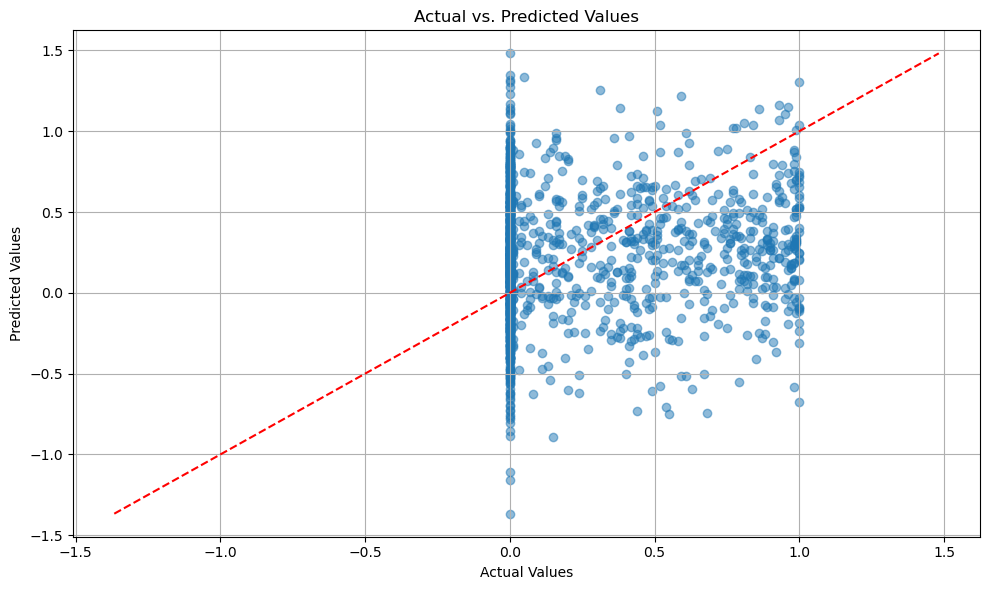

In [23]:
# Testing data plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)

min_val = min(min(y_test), min(y_pred_test))
max_val = max(max(y_test), max(y_pred_test))
print("Min:", min_val, ", Max:", max_val)
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.tight_layout()
plt.show()

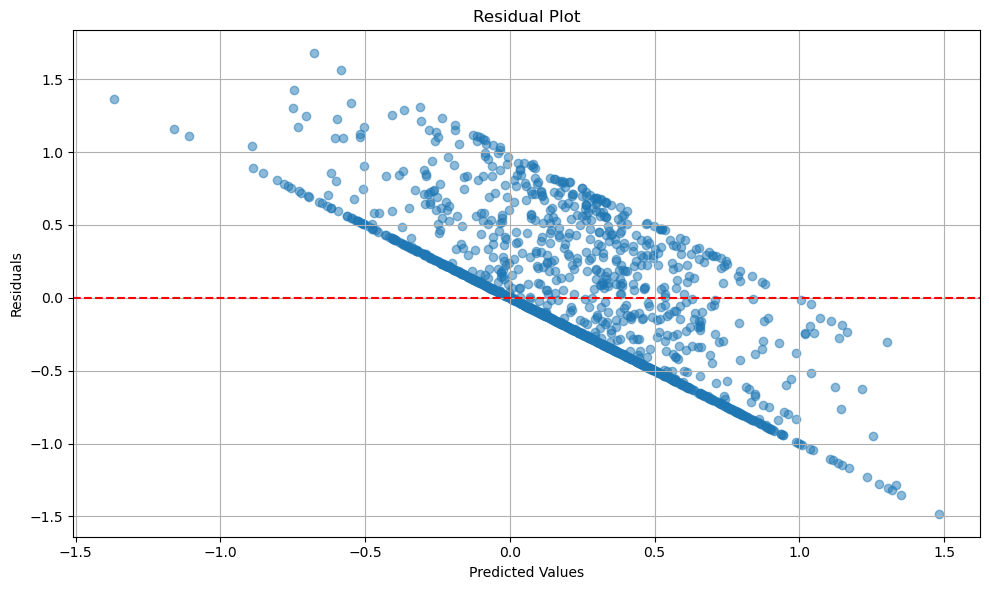

In [24]:
# Residuals plot
residuals = y_test - y_pred_test
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


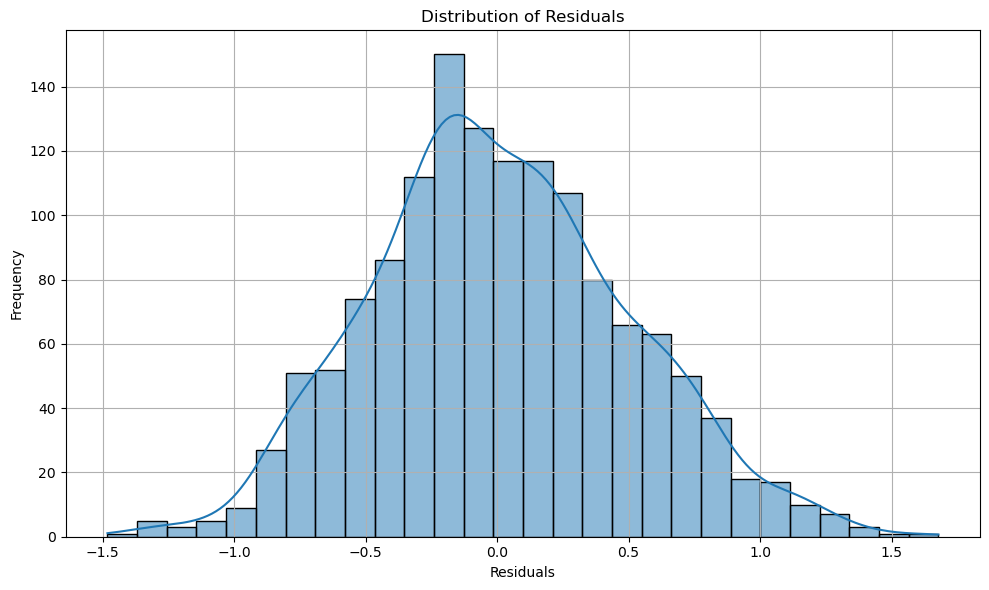

In [25]:
# Residuals distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()


Iteration 1, loss = 0.64884284
Iteration 2, loss = 0.29933492
Iteration 3, loss = 0.19853375
Iteration 4, loss = 0.09663620
Iteration 5, loss = 0.07521312
Iteration 6, loss = 0.06231927
Iteration 7, loss = 0.04259018
Iteration 8, loss = 0.03015217
Iteration 9, loss = 0.02393636
Iteration 10, loss = 0.01706858
Iteration 11, loss = 0.01192064
Iteration 12, loss = 0.00912403
Iteration 13, loss = 0.00669928
Iteration 14, loss = 0.00506326
Iteration 15, loss = 0.00379520
Iteration 16, loss = 0.00250533
Iteration 17, loss = 0.00211679
Iteration 18, loss = 0.00161283
Iteration 19, loss = 0.00114305
Iteration 20, loss = 0.00088293
Iteration 21, loss = 0.00077794
Iteration 22, loss = 0.00046831
Iteration 23, loss = 0.00042639
Iteration 24, loss = 0.00035597
Iteration 25, loss = 0.00025589
Iteration 26, loss = 0.00020103
Iteration 27, loss = 0.00018449
Iteration 28, loss = 0.00012892
Iteration 29, loss = 0.00011879
Iteration 30, loss = 0.00009204
Iteration 31, loss = 0.00008171
Iteration 32, los

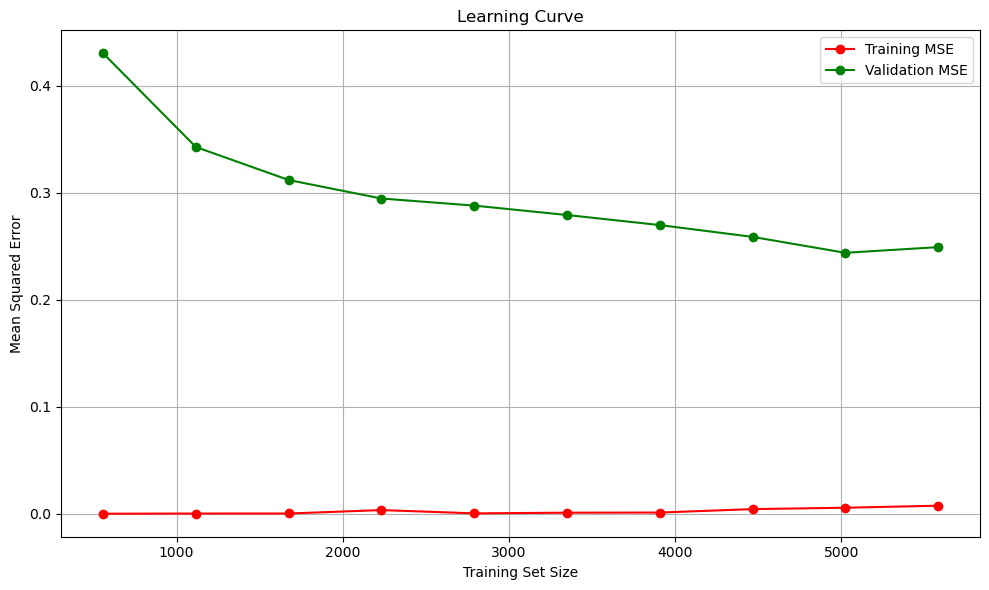

In [26]:
# Learning curve
# mlp = MLPRegressor(
#     hidden_layer_sizes=(64, 32),
#     activation='relu',
#     solver='adam',
#     alpha=0.0001,
#     batch_size='auto',
#     learning_rate='adaptive',
#     max_iter=300,
#     random_state=42,
#     verbose=True
# )

train_sizes, train_scores, test_scores = learning_curve(
    mlp, X_scaled, y, train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='neg_mean_squared_error')

train_scores_mean = -np.mean(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training MSE')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Validation MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
